In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from MyLovelyFunctions import *

In [2]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['start_year']>1990].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['length']<80].copy()
rainfall_events_all_df['random_variable'] = np.random.normal(size=len(rainfall_events_all_df))

In [3]:
short_events = rainfall_events_all_df[rainfall_events_all_df['length']<10].copy()
med_events = rainfall_events_all_df[(rainfall_events_all_df['length']>10) & (rainfall_events_all_df['length'] < 50)].copy()
long_events = rainfall_events_all_df[(rainfall_events_all_df['length']>50) & (rainfall_events_all_df['length'] < 80)].copy()

In [15]:
df = rainfall_events_all_df
annual_mean_d50 = (df.groupby("start_year", observed=True)["d50"].mean())
annual_mean_gini = (df.groupby("start_year", observed=True)["gini"].mean())
annual_mean_ppr = (df.groupby("start_year", observed=True)["peak_position_ratio"].mean())
annual_mean_tstd = (df.groupby("start_year", observed=True)["time_based_std"].mean())
annual_mean_mqi = (df.groupby("start_year", observed=True)["max_quartile_index"].mean())
annual_mean_dr = (df.groupby("start_year", observed=True)["dry_ratio"].mean())


annual_mean_cluster_n_cells_t50 = (df.groupby("start_year", observed=True)["cluster_n_cells_t50"].mean())
annual_mean_cluster_n_cells_t60 = (df.groupby("start_year", observed=True)["cluster_n_cells_t60"].mean())
annual_mean_cluster_n_cells_t80 = (df.groupby("start_year", observed=True)["cluster_n_cells_t80"].mean())

In [ ]:
fig, axs = plt.subplots(nrows = 3, figsize=(10, 7), sharex=False)

make_subplot(axs[0], annual_mean_cluster_n_cells_t50, "Num cells", "Annual mean per-event spatial extent", 2, "cells")
make_subplot(axs[1], annual_mean_cluster_n_cells_t60, "Num cells", "Annual mean per-event spatial extent",2, "cells")

make_subplot(axs[2], annual_mean_cluster_n_cells_t80, "Num cells", "Annual mean per-event spatial extent",2, "cells")

plt.tight_layout()

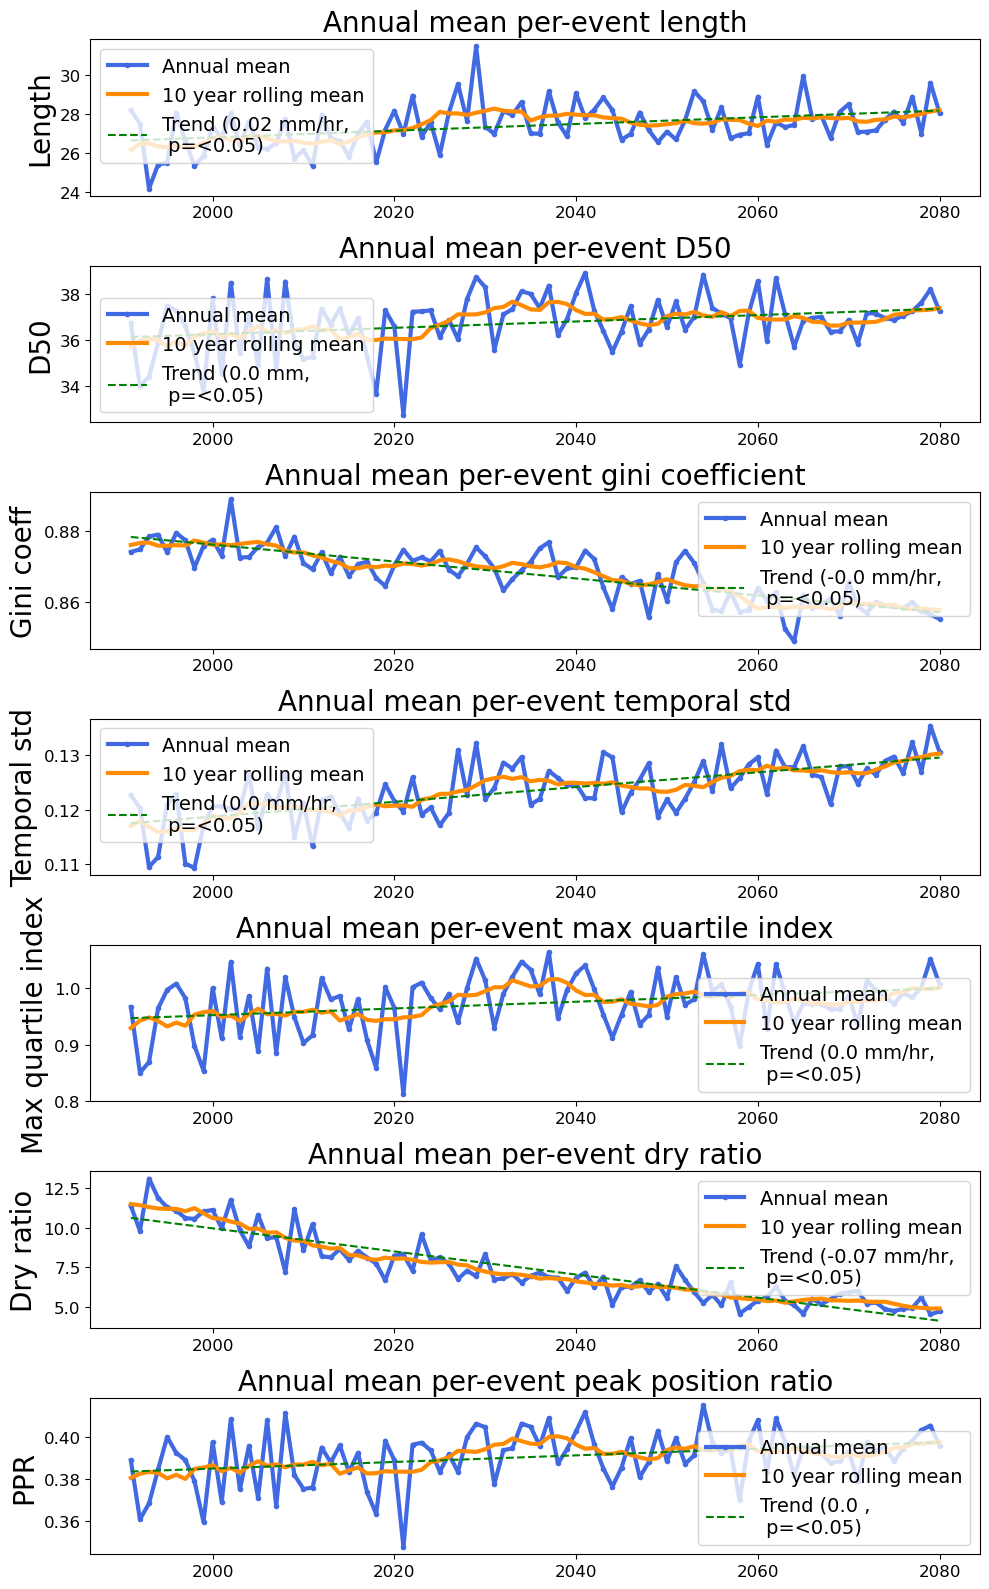

In [16]:
fig, axs = plt.subplots(nrows = 7, figsize=(10, 16), sharex=False)

make_subplot(axs[0], annual_mean_length, "Length", "Annual mean per-event length", 
             2, "mm/hr")
make_subplot(axs[1], annual_mean_d50, "D50", "Annual mean per-event D50",1, "mm")
make_subplot(axs[2], annual_mean_gini, "Gini coeff", "Annual mean per-event gini coefficient", 
             2, "mm/hr")
make_subplot(axs[3], annual_mean_tstd, "Temporal std", "Annual mean per-event temporal std", 
             2, "mm/hr")
make_subplot(axs[4], annual_mean_mqi, "Max quartile index", "Annual mean per-event max quartile index", 
             2, "mm/hr")
make_subplot(axs[5], annual_mean_dr, "Dry ratio", "Annual mean per-event dry ratio", 
             2, "mm/hr")
make_subplot(axs[6], annual_mean_ppr, "PPR", "Annual mean per-event peak position ratio",1, "")

plt.tight_layout()

In [13]:
df = rainfall_events_all_df
annual_mean_length = (df.groupby("start_year", observed=True)["length"].mean())
annual_mean_length_active_rain = (df.groupby("start_year", observed=True)["length_of_active_rain"].mean())
annual_mean_d50 = (df.groupby("start_year", observed=True)["d50_n"].mean())
annual_mean_gini = (df.groupby("start_year", observed=True)["gini_n"].mean())
annual_mean_ppr = (df.groupby("start_year", observed=True)["peak_position_ratio_n"].mean())
annual_mean_tstd = (df.groupby("start_year", observed=True)["time_based_std_n"].mean())
annual_mean_mqi = (df.groupby("start_year", observed=True)["max_quartile_index_n"].mean())
annual_mean_dr = (df.groupby("start_year", observed=True)["dry_ratio_n"].mean())

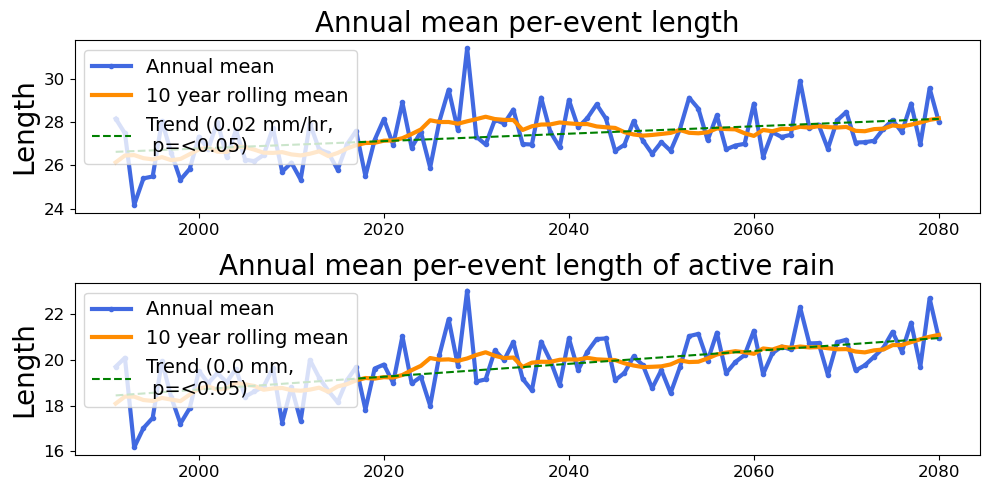

In [14]:
fig, axs = plt.subplots(nrows = 2, figsize=(10, 5), sharex=False)

make_subplot(axs[0], annual_mean_length, "Length", "Annual mean per-event length", 
             2, "mm/hr")
make_subplot(axs[1], annual_mean_length_active_rain, "Length", "Annual mean per-event length of active rain",1, "mm")

plt.tight_layout()

In [26]:
early_events = rainfall_events_all_df[rainfall_events_all_df['start_year']>2020].copy()
med_events = rainfall_events_all_df[(rainfall_events_all_df['start_year']>2020) & (rainfall_events_all_df['start_year'] < 2050)].copy()
late_events = rainfall_events_all_df[(rainfall_events_all_df['start_year']>2050)].copy()

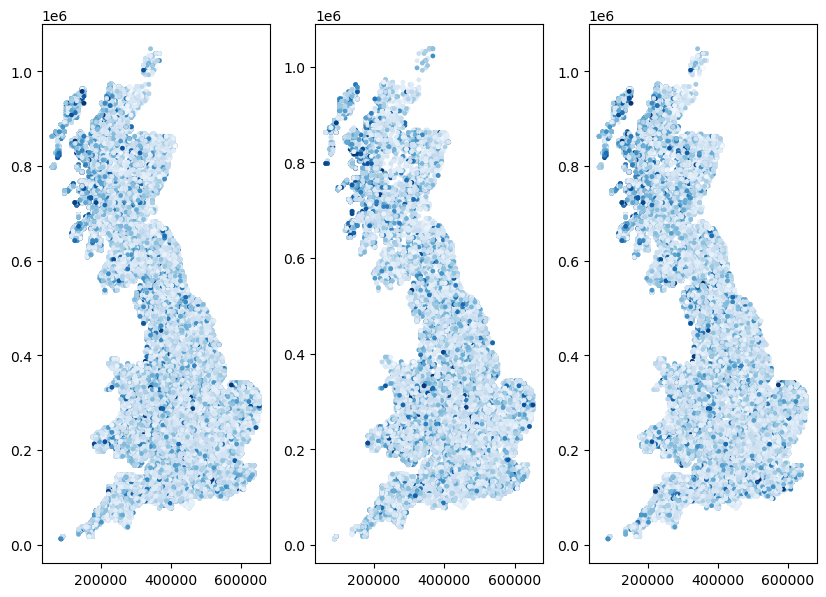

In [31]:
fig, axs = plt.subplots(figsize=(10, 7), ncols=3)
for ax_num, df in enumerate([early_events, med_events, late_events]):
    sc = axs[ax_num].scatter(df['x_coord'], df['y_coord'], c=df['length'], cmap='Blues', s=6, alpha=1)
#     plt.colorbar(sc, label='Length')
#     ax.set_aspect('equal')
#     plt.show()

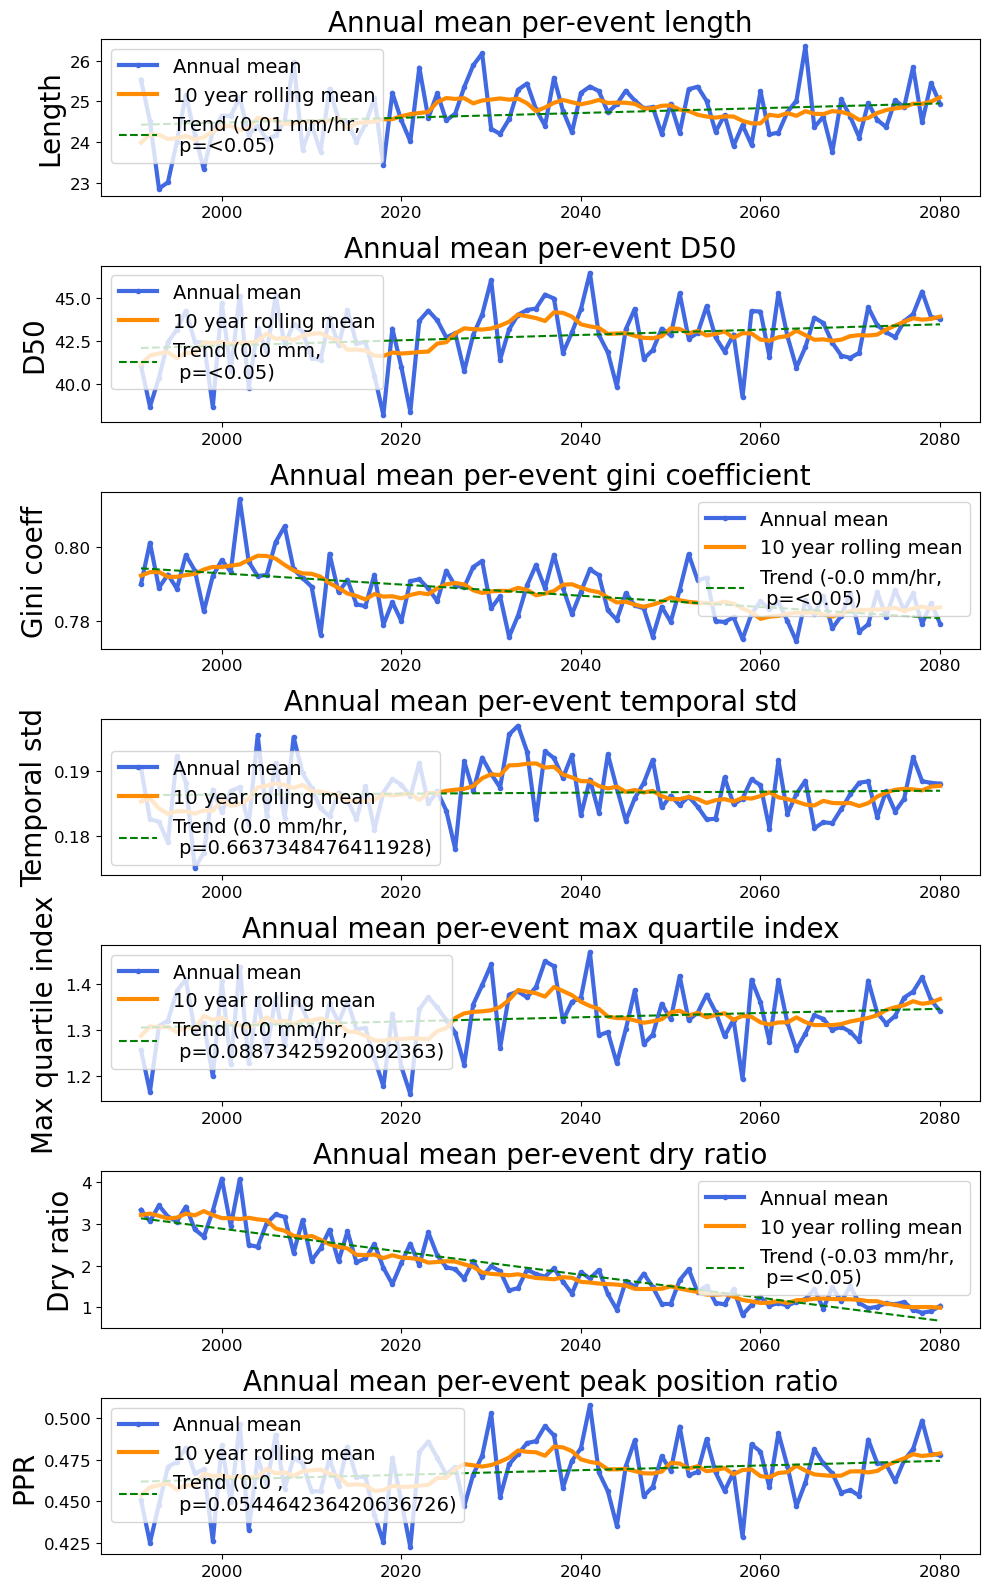

In [9]:
fig, axs = plt.subplots(nrows = 7, figsize=(10, 16), sharex=False)

make_subplot(axs[0], annual_mean_length, "Length", "Annual mean per-event length", 
             2, "mm/hr")
make_subplot(axs[1], annual_mean_d50, "D50", "Annual mean per-event D50",1, "mm")
make_subplot(axs[2], annual_mean_gini, "Gini coeff", "Annual mean per-event gini coefficient", 
             2, "mm/hr")
make_subplot(axs[3], annual_mean_tstd, "Temporal std", "Annual mean per-event temporal std", 
             2, "mm/hr")
make_subplot(axs[4], annual_mean_mqi, "Max quartile index", "Annual mean per-event max quartile index", 
             2, "mm/hr")
make_subplot(axs[5], annual_mean_dr, "Dry ratio", "Annual mean per-event dry ratio", 
             2, "mm/hr")
make_subplot(axs[6], annual_mean_ppr, "PPR", "Annual mean per-event peak position ratio",1, "")

plt.tight_layout()